In [1]:
import os
print(os.getcwd())

c:\Users\Bismillah Traders\OneDrive\Desktop\Ecommerce Sales data analysis


In [2]:
import pandas as pd

In [21]:
import matplotlib.pyplot as plt

In [22]:
import seaborn as sns

In [3]:
# Upoading and reading data
df = pd.read_csv("data/ecommerce.csv") 
print(df.head())

   order_id     product     category  price  quantity        date       city
0      1001      Laptop  Electronics  80000         1  2024-01-10     Lahore
1      1002       Shoes      Fashion   5000         2  2024-01-11    Karachi
2      1003       Phone  Electronics  60000         1  2024-01-12  Islamabad
3      1004     T-shirt      Fashion   2000         3  2024-02-01     Lahore
4      1005  Headphones  Electronics   3000         2  2024-02-05    Karachi


In [4]:
# Check missing values
print(df.isnull().sum())

order_id    0
product     0
category    0
price       0
quantity    0
date        0
city        0
dtype: int64


In [5]:
#Checking data types
print(df.dtypes)

order_id     int64
product     object
category    object
price        int64
quantity     int64
date        object
city        object
dtype: object


In [6]:

df['date'] = pd.to_datetime(df['date'])

In [7]:
# Create a new column: revenue
df['revenue'] = df['price'] * df['quantity']

In [8]:
# Feature Engineering

# Ensure 'price' and 'quantity' are numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

In [9]:
print(df.head())

   order_id     product     category  price  quantity       date       city  \
0      1001      Laptop  Electronics  80000         1 2024-01-10     Lahore   
1      1002       Shoes      Fashion   5000         2 2024-01-11    Karachi   
2      1003       Phone  Electronics  60000         1 2024-01-12  Islamabad   
3      1004     T-shirt      Fashion   2000         3 2024-02-01     Lahore   
4      1005  Headphones  Electronics   3000         2 2024-02-05    Karachi   

   revenue  
0    80000  
1    10000  
2    60000  
3     6000  
4     6000  


In [10]:
# how much money the business made overall.
# Total revenue
total_revenue = df['revenue'].sum()
print(f"Total Revenue: {total_revenue}")

Total Revenue: 384000


In [11]:
# products sell most by revenue?
# Revenue by product
product_revenue = df.groupby('product')['revenue'].sum().sort_values(ascending=False)
print(product_revenue)

product
Phone         180000
Laptop        160000
Headphones     15000
Shoes          15000
T-shirt        14000
Name: revenue, dtype: int64


In [12]:
# Revenue by category
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print(category_revenue)

category
Electronics    355000
Fashion         29000
Name: revenue, dtype: int64


In [13]:
# Revenue by city
city_revenue = df.groupby('city')['revenue'].sum().sort_values(ascending=False)
print(city_revenue)

city
Islamabad    148000
Karachi      136000
Lahore       100000
Name: revenue, dtype: int64


In [41]:
# Extract month
df['month'] = df['date'].dt.to_period('M')

In [43]:
# Revenue by month
monthly_revenue=df.groupby('month')['revenue'].sum()

In [44]:
# Monthly trends
df['month'] = df['date'].dt.to_period('M')
monthly_revenue = df.groupby('month')['revenue'].sum()
print("\nRevenue by Month:\n", monthly_revenue)


Revenue by Month:
 month
2024-01    150000
2024-02     92000
2024-03    142000
Freq: M, Name: revenue, dtype: int64


In [39]:
# Step 5: Exploratory Data Analysis

# Total Revenue
total_revenue = df['revenue'].sum()
print(f"Total Revenue: {total_revenue}")

Total Revenue: 384000


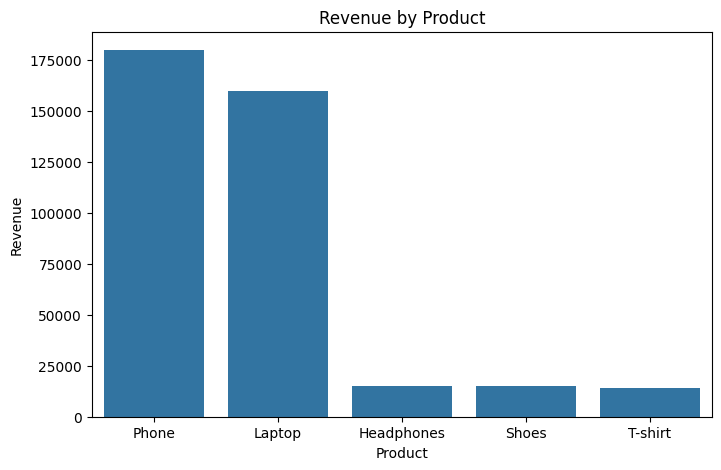

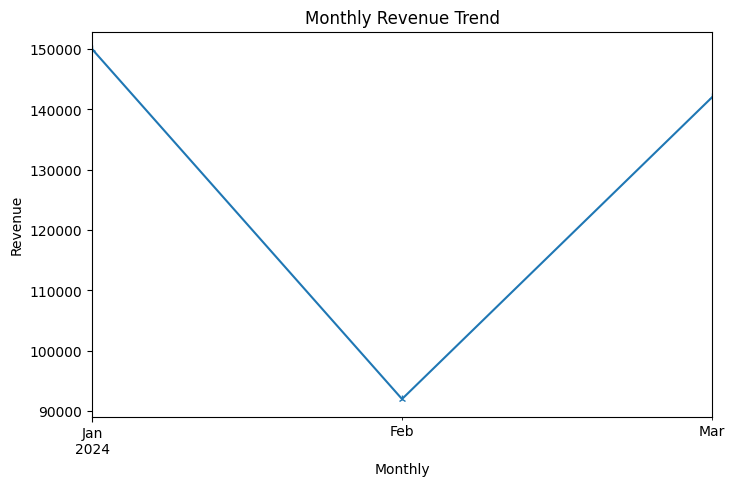

In [34]:
# Revenue by product
plt.figure(figsize=(8,5))
sns.barplot(x=product_revenue.index, y=product_revenue.values)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.show()

# Monthly revenue trend
plt.figure(figsize=(8,5))
monthly_revenue.plot(marker='2')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Monthly")
plt.show()

In [ ]:
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_revenue.index, y=category_revenue.values)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

Shows which category performs best (electronics, fashion, etc.).

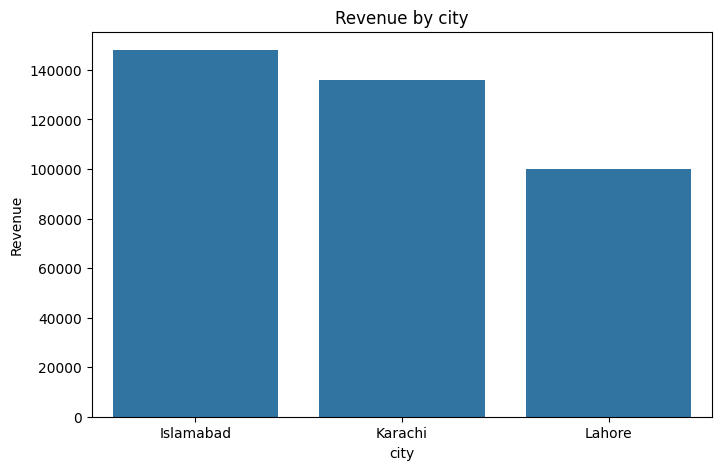

In [49]:
city_revenue = df.groupby('city')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=city_revenue.index, y=city_revenue.values)

plt.title("Revenue by city")
plt.xlabel("city")
plt.ylabel("Revenue")

plt.show()